# NB-C · Random Forest + Logistic Regression — 154 Classes

Both models use the same stat feature CSVs (126 channels x 5 stats = 630 features).
Results -> `results/rf_154/` and `results/lr_154/`


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os, json, time
import numpy as np
import pandas as pd
import joblib, gzip, shutil
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

PROJECT_DIR = ('/content/drive/MyDrive/Consultant/Colab_Notebooks/'
               'Obrown_Dissertation_NU_25/OBrown_DIS9300_v2')
TRAIN_CSV = os.path.join(PROJECT_DIR, 'ASL_154_train_rf.csv')
TEST_CSV  = os.path.join(PROJECT_DIR, 'ASL_154_test_rf.csv')
LE_PATH   = os.path.join(PROJECT_DIR, 'ASL_154_label_encoder.pkl')
RF_DIR    = os.path.join(PROJECT_DIR, 'results', 'rf_154')
LR_DIR    = os.path.join(PROJECT_DIR, 'results', 'lr_154')
os.makedirs(RF_DIR, exist_ok=True)
os.makedirs(LR_DIR, exist_ok=True)

print(f'Train: {TRAIN_CSV}')
print(f'Test : {TEST_CSV}')


Train: /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/ASL_154_train_rf.csv
Test : /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/ASL_154_test_rf.csv


In [3]:
le = joblib.load(LE_PATH)
N_CLASSES = len(le.classes_)

df_tr = pd.read_csv(TRAIN_CSV)
df_te = pd.read_csv(TEST_CSV)

feat_cols = [c for c in df_tr.columns if c not in ('filename','gloss')]
X_train_raw = df_tr[feat_cols].values.astype(np.float32)
X_test_raw  = df_te[feat_cols].values.astype(np.float32)
y_train = le.transform(df_tr['gloss'].astype(str))
y_test  = le.transform(df_te['gloss'].astype(str))

# Column-mean imputation
col_means = np.nanmean(X_train_raw, axis=0)
col_means = np.where(np.isnan(col_means), 0, col_means)
for X in [X_train_raw, X_test_raw]:
    for c in range(X.shape[1]):
        m = np.isnan(X[:,c])
        if m.any(): X[m,c] = col_means[c]

print(f'Features : {X_train_raw.shape[1]}  (126ch x 5 stats)')
print(f'Train    : {X_train_raw.shape}  Classes: {N_CLASSES}')
print(f'Test     : {X_test_raw.shape}')


Features : 630  (126ch x 5 stats)
Train    : (926, 630)  Classes: 154
Test     : (309, 630)


In [4]:
import warnings, matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

def full_eval(y_true, y_proba, le, model_name, model_tag, results_dir):
    os.makedirs(results_dir, exist_ok=True)
    N_CLS  = len(le.classes_)
    y_pred = np.argmax(y_proba, axis=1)
    n      = len(y_true)

    acc      = accuracy_score(y_true, y_pred)
    top5     = sum(y_true[k] in np.argsort(y_proba[k])[-5:] for k in range(n)) / n
    f1_mac   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_mac = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',    zero_division=0)

    metrics = {'model':model_name,'top1_acc':float(acc),'top5_acc':float(top5),
               'f1_macro':float(f1_mac),'f1_weighted':float(f1_wt),
               'precision_macro':float(prec_mac),'recall_macro':float(rec_mac),
               'n_test':int(n),'n_classes':int(N_CLS)}
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)

    # Per-class report
    report = classification_report(y_true, y_pred,
        target_names=[str(c) for c in le.classes_],
        output_dict=True, zero_division=0)
    with open(os.path.join(results_dir,f'{model_tag}_report.json'),'w') as f:
        json.dump(report,f,indent=2)

    # Confusion matrix chart
    cm = confusion_matrix(y_true, y_pred)
    n_show = min(50, cm.shape[0])
    fig,ax = plt.subplots(figsize=(14,12))
    im = ax.imshow(cm[:n_show,:n_show],cmap='Blues',aspect='auto')
    ax.set_title(f'{model_name}\nConfusion Matrix (top {n_show} classes)',
                 fontweight='bold',fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ticks=np.arange(n_show)
    lbls=[str(le.classes_[i]) for i in range(n_show)]
    ax.set_xticks(ticks); ax.set_xticklabels(lbls,rotation=90,fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(lbls,fontsize=6)
    plt.colorbar(im,ax=ax,fraction=0.03); plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_confusion_chart.png'),dpi=150)
    plt.show()
    import pandas as pd
    pd.DataFrame(cm,index=[str(c) for c in le.classes_],
                 columns=[str(c) for c in le.classes_]).to_csv(
        os.path.join(results_dir,f'{model_tag}_confusion_table.csv'))

    # ROC
    y_bin=label_binarize(y_true,classes=np.arange(N_CLS))
    fpr_grid=np.linspace(0,1,300)
    tprs,aucs,cls_pos=[],[],[]
    for i in range(N_CLS):
        if y_bin[:,i].sum()==0: continue
        fpr,tpr,_=roc_curve(y_bin[:,i],y_proba[:,i])
        aucs.append(auc(fpr,tpr)); tprs.append(np.interp(fpr_grid,fpr,tpr)); cls_pos.append(i)
    mean_tpr=np.mean(tprs,axis=0); mean_tpr[0]=0.0; mean_tpr[-1]=1.0
    macro_auc=np.mean(aucs)
    sorted_a=sorted(zip(aucs,cls_pos),reverse=True)
    top5i=[x for _,x in sorted_a[:5]]; bot5i=[x for _,x in sorted_a[-5:]]
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    ax=axes[0]
    ax.plot(fpr_grid,mean_tpr,color='navy',lw=2,label=f'Macro AUC={macro_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax.set_xlim([0,1]);ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11);ax.set_ylabel('TPR',fontsize=11)
    ax.set_title(f'{model_name}\nMacro-Avg ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=9);ax.grid(alpha=0.3)
    ax=axes[1]
    ct=['#1f77b4','#2ca02c','#d62728','#9467bd','#8c564b']
    cb=['#e377c2','#7f7f7f','#bcbd22','#17becf','#ff7f0e']
    for ci,col in zip(top5i,ct):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,label=f'Top:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    for ci,col in zip(bot5i,cb):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,ls='--',label=f'Bot:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]);ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11);ax.set_ylabel('TPR',fontsize=11)
    ax.set_title('Best/Worst 5 Classes ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=7);ax.grid(alpha=0.3)
    plt.suptitle(f'{model_name} | {N_CLS} classes | Macro AUC={macro_auc:.3f}',fontsize=11,y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_roc.png'),dpi=150,bbox_inches='tight')
    plt.show()
    metrics['macro_auc']=float(macro_auc)
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)

    # Metrics bar
    fig,ax=plt.subplots(figsize=(10,5))
    mlbls=['Top-1\nAcc','Top-5\nAcc','Prec\n(mac)','Rec\n(mac)','F1\n(mac)','AUC\n(mac)']
    mvals=[acc,top5,prec_mac,rec_mac,f1_mac,macro_auc]
    cols=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
    bars=ax.bar(mlbls,mvals,color=cols,width=0.6)
    ax.set_ylim(0,min(1.0,max(mvals)*1.25+0.05))
    ax.set_title(f'{model_name} — Test Metrics',fontweight='bold',fontsize=12)
    for bar,v in zip(bars,mvals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
    ax.grid(axis='y',alpha=0.3);plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_metrics_bar.png'),dpi=150)
    plt.show()

    print(f'\n== {model_name} ==')
    print(f'  Top-1: {acc*100:.2f}%  Top-5: {top5*100:.2f}%')
    print(f'  Prec : {prec_mac*100:.2f}%  Rec: {rec_mac*100:.2f}%')
    print(f'  F1   : {f1_mac*100:.2f}%  AUC: {macro_auc:.4f}')
    return metrics

print('full_eval() defined')


full_eval() defined


Training Random Forest (100 trees)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.2s finished


Done in 0.1 min


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


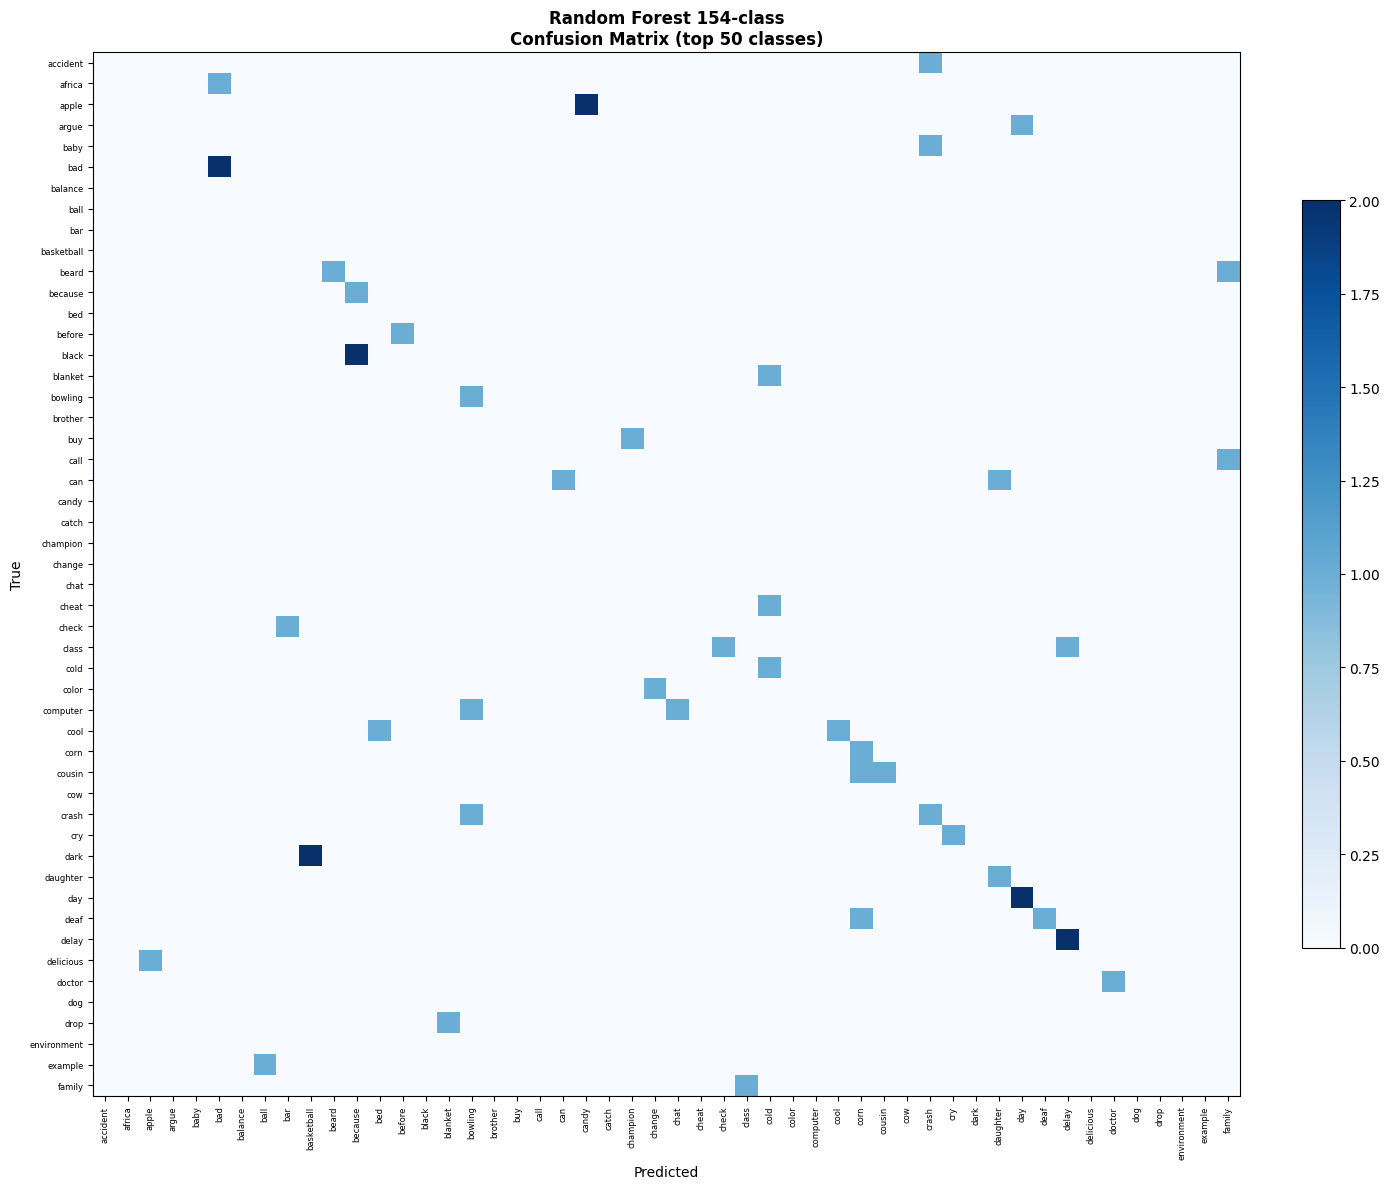

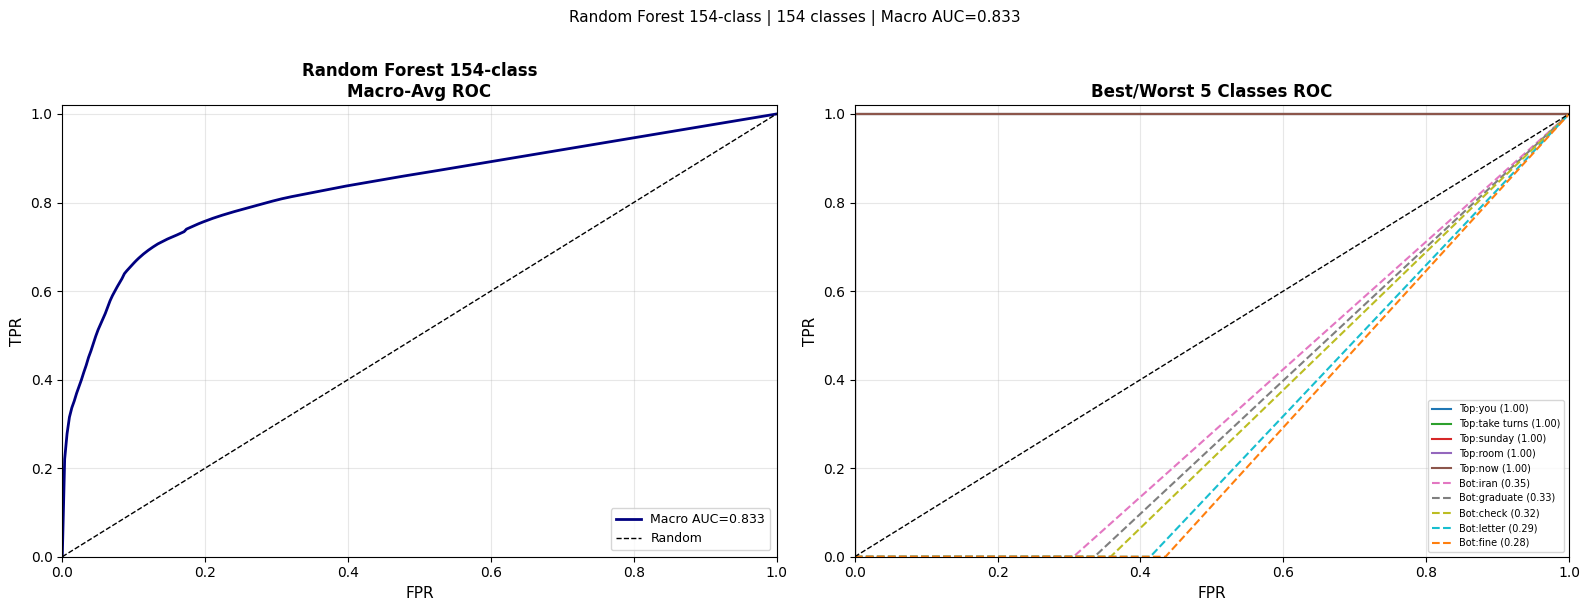

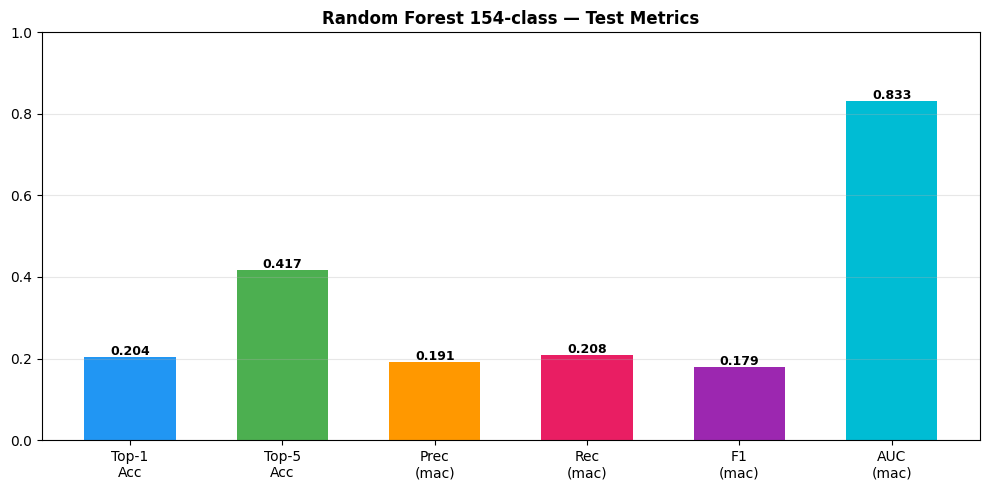


== Random Forest 154-class ==
  Top-1: 20.39%  Top-5: 41.75%
  Prec : 19.08%  Rec: 20.78%
  F1   : 17.88%  AUC: 0.8327
Top 5 features: ['0_0_z_mean', '0_0_z_median', '0_0_z_max', '0_1_z_mean', '0_17_x_std']


In [5]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_model_path = os.path.join(RF_DIR,'rf_154_model.pkl')
if os.path.exists(rf_model_path):
    print('[SKIP] Loading Random Forest model...')
    rf_clf = joblib.load(rf_model_path)
else:
    print('Training Random Forest (100 trees)...')
    t0 = time.time()
    rf_clf = RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                    n_jobs=-1, random_state=42, verbose=1)
    rf_clf.fit(X_train_raw, y_train)
    print(f'Done in {(time.time()-t0)/60:.1f} min')
    joblib.dump(rf_clf, rf_model_path)
    with open(rf_model_path,'rb') as fi, gzip.open(rf_model_path+'.gz','wb') as fo:
        shutil.copyfileobj(fi, fo)

rf_proba = rf_clf.predict_proba(X_test_raw)
np.save(os.path.join(RF_DIR,'rf_154_proba_test.npy'), rf_proba)
rf_results = full_eval(y_test, rf_proba, le,
                       'Random Forest 154-class', 'rf_154', RF_DIR)

# Feature importances
fi_df = pd.DataFrame({'feature': feat_cols, 'importance': rf_clf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=False)
fi_df.to_csv(os.path.join(RF_DIR,'rf_154_feature_importances.csv'), index=False)
print(f'Top 5 features: {fi_df.head(5)["feature"].tolist()}')


Training Logistic Regression...
Done in 0.1 min


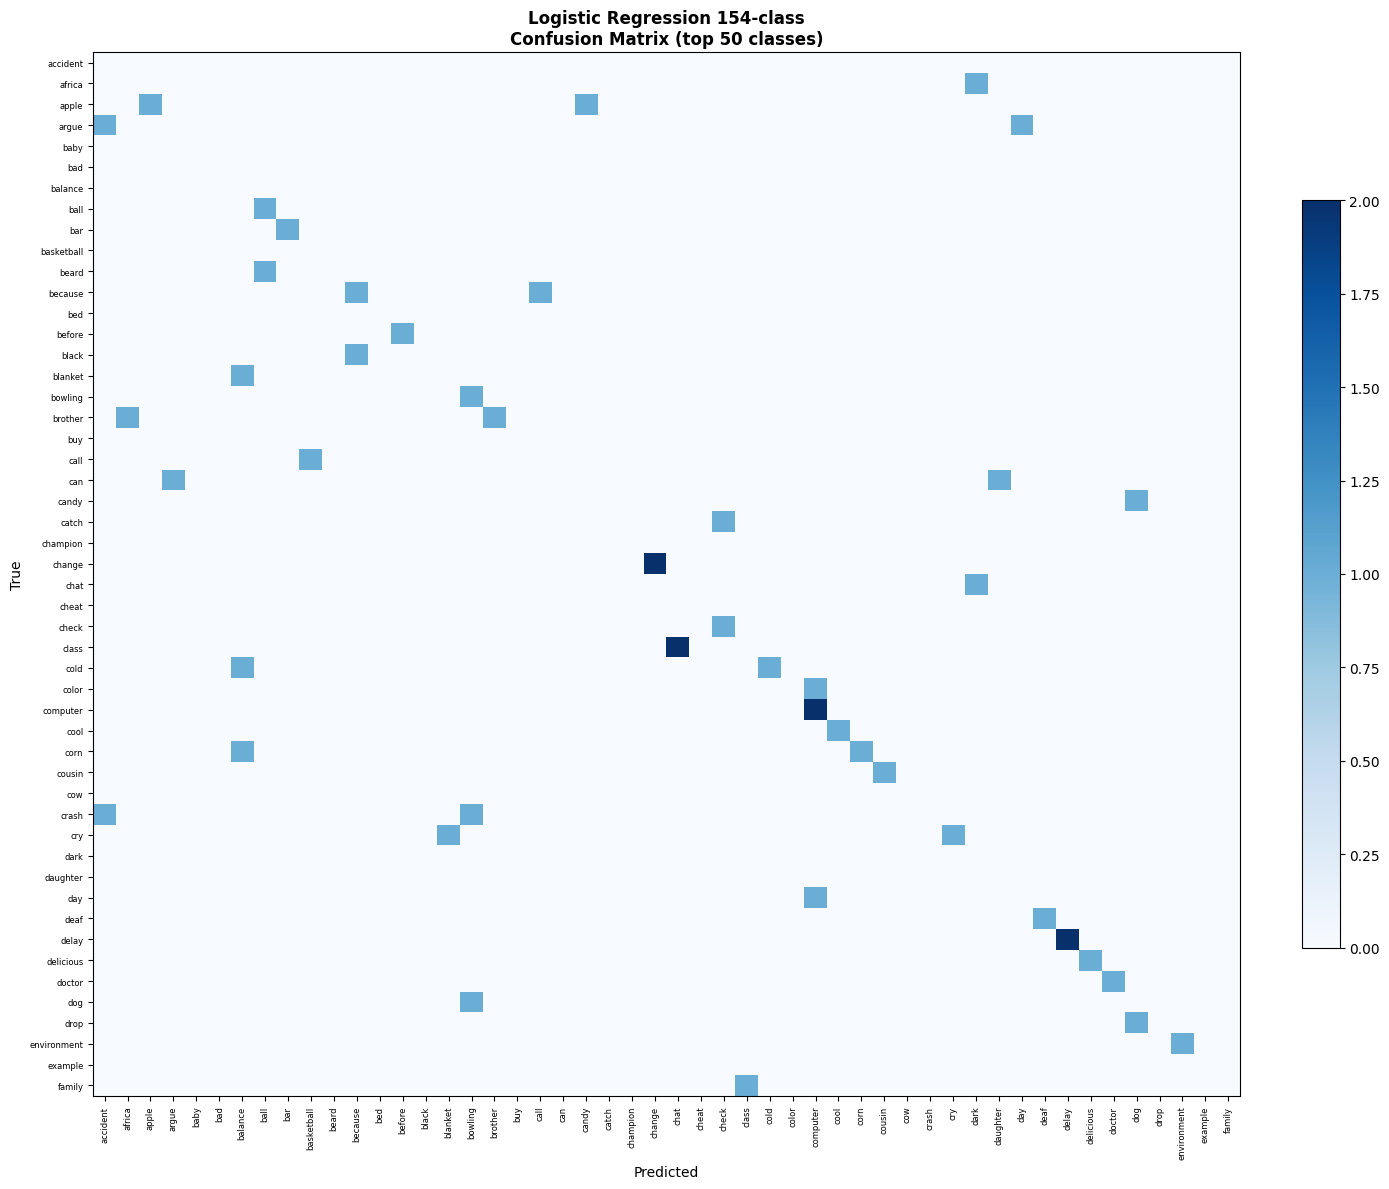

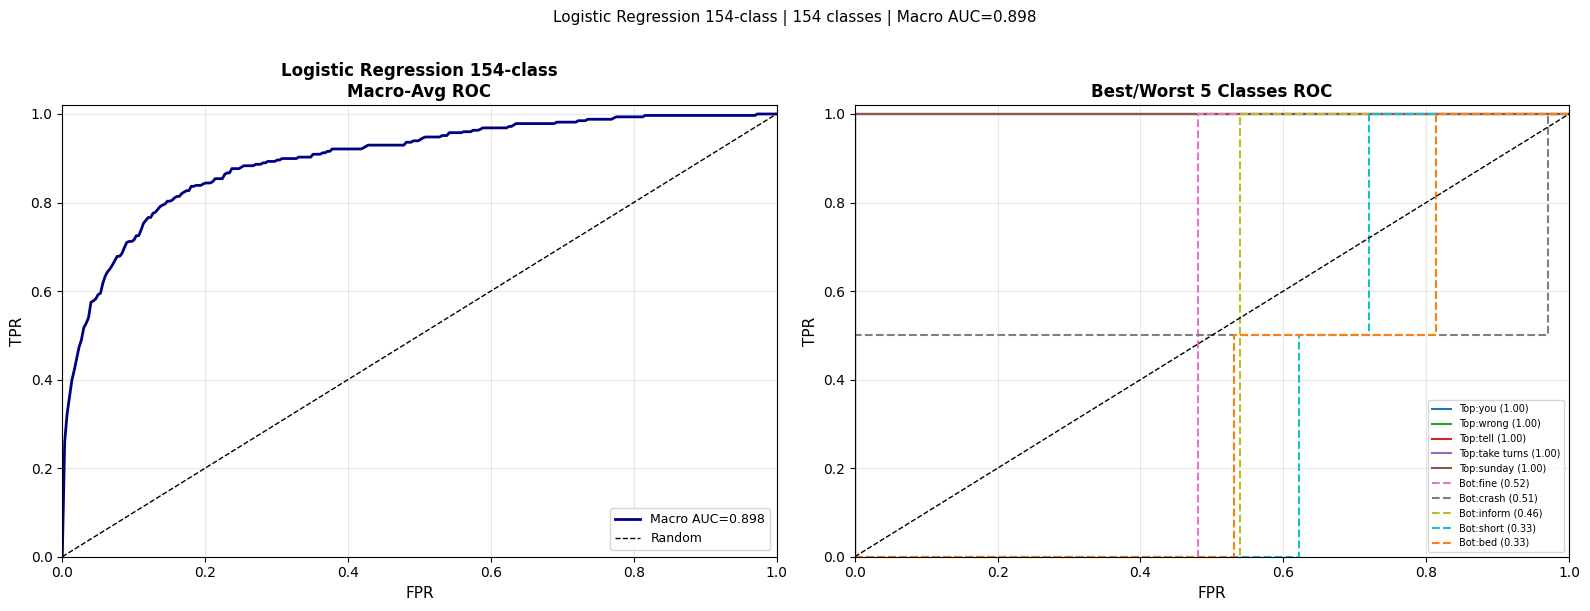

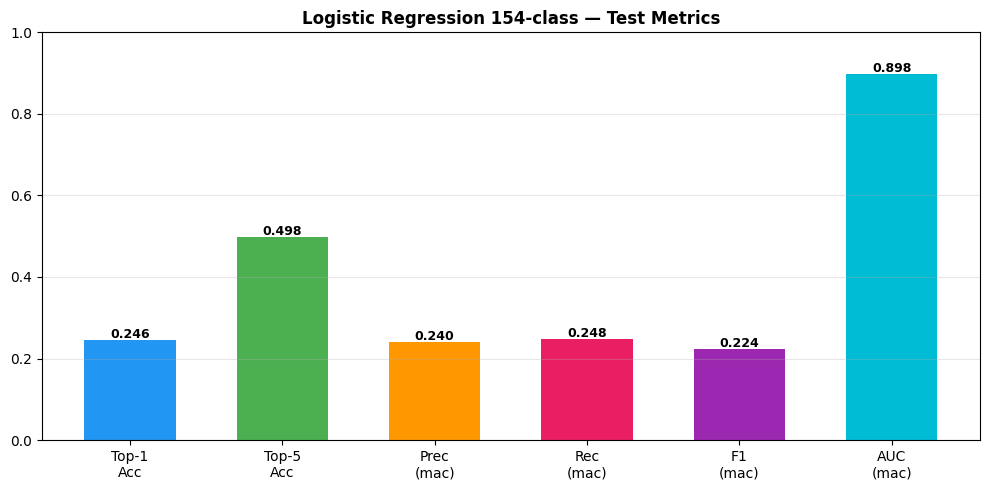


== Logistic Regression 154-class ==
  Top-1: 24.60%  Top-5: 49.84%
  Prec : 23.96%  Rec: 24.78%
  F1   : 22.42%  AUC: 0.8980


In [6]:
# ── Logistic Regression ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_raw)
X_te_sc = scaler.transform(X_test_raw)
joblib.dump(scaler, os.path.join(LR_DIR,'lr_154_scaler.pkl'))

lr_model_path = os.path.join(LR_DIR,'lr_154_model.pkl')
if os.path.exists(lr_model_path):
    print('[SKIP] Loading LR model...')
    lr_clf = joblib.load(lr_model_path)
else:
    print('Training Logistic Regression...')
    t0 = time.time()
    lr_clf = LogisticRegression(C=1.0, solver='lbfgs', max_iter=200,
                                n_jobs=-1, random_state=42)
    lr_clf.fit(X_tr_sc, y_train)
    print(f'Done in {(time.time()-t0)/60:.1f} min')
    joblib.dump(lr_clf, lr_model_path)
    with open(lr_model_path,'rb') as fi, gzip.open(lr_model_path+'.gz','wb') as fo:
        shutil.copyfileobj(fi, fo)

lr_proba = lr_clf.predict_proba(X_te_sc)
np.save(os.path.join(LR_DIR,'lr_154_proba_test.npy'), lr_proba)
lr_results = full_eval(y_test, lr_proba, le,
                       'Logistic Regression 154-class', 'lr_154', LR_DIR)



  NB-C FINAL COMPARISON — 154 Classes
  Model                      Top-1   Top-5   F1 Mac      AUC
-------------------------------------------------------
  Random Forest             20.39%  41.75%   17.88%   0.8327
  Logistic Regression       24.60%  49.84%   22.42%   0.8980


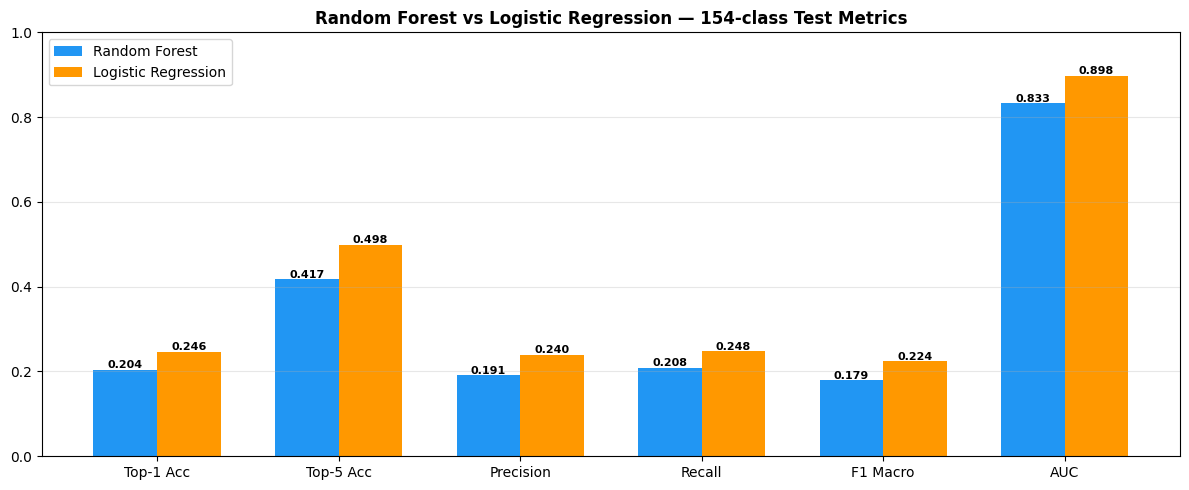

Comparison saved to results/nbc_154_comparison.json


In [7]:
# ── Final Comparison ─────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  NB-C FINAL COMPARISON — 154 Classes')
print('='*55)
print(f'  {"Model":<25} {"Top-1":>6}  {"Top-5":>6}  {"F1 Mac":>7}  {"AUC":>7}')
print('-'*55)
for name, r in [('Random Forest', rf_results), ('Logistic Regression', lr_results)]:
    print(f'  {name:<25} {r["top1_acc"]*100:>5.2f}%  '
          f'{r["top5_acc"]*100:>5.2f}%  '
          f'{r["f1_macro"]*100:>6.2f}%  '
          f'{r["macro_auc"]:>7.4f}')
print('='*55)

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 5))
metrics_labels = ['Top-1 Acc', 'Top-5 Acc', 'Precision', 'Recall', 'F1 Macro', 'AUC']
rf_vals = [rf_results['top1_acc'], rf_results['top5_acc'],
           rf_results['precision_macro'], rf_results['recall_macro'],
           rf_results['f1_macro'], rf_results['macro_auc']]
lr_vals = [lr_results['top1_acc'], lr_results['top5_acc'],
           lr_results['precision_macro'], lr_results['recall_macro'],
           lr_results['f1_macro'], lr_results['macro_auc']]

x = np.arange(len(metrics_labels))
w = 0.35
bars1 = ax.bar(x - w/2, rf_vals, w, label='Random Forest', color='#2196F3')
bars2 = ax.bar(x + w/2, lr_vals, w, label='Logistic Regression', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylim(0, min(1.0, max(rf_vals + lr_vals) * 1.25 + 0.05))
ax.set_title('Random Forest vs Logistic Regression — 154-class Test Metrics',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(bars1, rf_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
for bar, v in zip(bars2, lr_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()

COMPARE_DIR = os.path.join(PROJECT_DIR, 'results')
plt.savefig(os.path.join(COMPARE_DIR, 'nbc_154_rf_vs_lr_comparison.png'), dpi=150)
plt.show()

# Save combined JSON
combined = {'random_forest': rf_results, 'logistic_regression': lr_results}
with open(os.path.join(COMPARE_DIR, 'nbc_154_comparison.json'), 'w') as f:
    json.dump(combined, f, indent=2)
print('Comparison saved to results/nbc_154_comparison.json')
